In [1]:
import os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

plt.rcParams['font.family'] = 'AppleGothic' # matplotlib 한글 폰트깨짐 문제 해결을 위함
cur_path = '.'
data_path = 'data'
train_file_name = 'train.csv'
test_file_name = 'test.csv'
submission_file_name = 'sample_submission.csv'

In [2]:
submission = pd.read_csv(os.path.join(cur_path, data_path, submission_file_name),encoding='utf-8')
train_raw = pd.read_csv(os.path.join(cur_path, data_path, train_file_name), encoding='utf-8')
test_raw = pd.read_csv(os.path.join(cur_path, data_path, test_file_name), encoding='utf-8')

In [3]:
train_raw

,ID,매물확인방식,보증금,월세,전용면적,해당층,총층,방향,방수,욕실수,주차가능여부,총주차대수,관리비,중개사무소,제공플랫폼,게재일,허위매물여부
0,TRAIN_0000,현장확인,402500000.0,470000,NaN,NaN,15.0,서향,1.0,1.0,가능,40.0,96,t93Nt6I2I0,B플랫폼,2024-10-09,0
1,TRAIN_0001,현장확인,170500000.0,200000,NaN,3.0,4.0,남동향,2.0,1.0,불가능,NaN,0,q39iV5J4E6,D플랫폼,2024-12-26,0
2,TRAIN_0002,전화확인,114000000.0,380000,NaN,2.0,3.0,동향,1.0,1.0,불가능,NaN,0,b03oE4G3F6,A플랫폼,2024-11-28,0
3,TRAIN_0003,현장확인,163500000.0,30000,36.30,3.0,9.0,남동향,2.0,1.0,가능,13.0,10,G52Iz8V2B9,A플랫폼,2024-11-26,0
4,TRAIN_0004,현장확인,346000000.0,530000,NaN,3.0,3.0,동향,2.0,1.0,불가능,NaN,0,N45gM0M7R0,B플랫폼,2024-06-25,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2447,TRAIN_2447,서류확인,159000000.0,550000,48.95,3.0,3.0,남향,2.0,1.0,불가능,NaN,0,d22DX4Y4P8,B플랫폼,2024-11-16,0
2448,TRAIN_2448,서류확인,158500000.0,750000,NaN,2.0,4.0,남향,1.0,1.0,불가능,NaN,2,g99sy3I3R8,A플랫폼,2024-10-06,0
2449,TRAIN_2449,전화확인,329000000.0,610000,17.50,8.0,20.0,남서향,1.0,1.0,가능,29.0,10,G52Iz8V2B9,B플랫폼,2024-05-15,0
2450,TRAIN_2450,현장확인,31000000.0,400000,22.87,8.0,9.0,남동향,2.0,1.0,가능,NaN,8,m69GM9O9B3,B플랫폼,2024-08-06,0


In [4]:
train_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2452 entries, 0 to 2451
Data columns (total 17 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ID      2452 non-null   object 
 1   매물확인방식  2452 non-null   object 
 2   보증금     2452 non-null   float64
 3   월세      2452 non-null   int64  
 4   전용면적    1665 non-null   float64
 5   해당층     2223 non-null   float64
 6   총층      2436 non-null   float64
 7   방향      2452 non-null   object 
 8   방수      2436 non-null   float64
 9   욕실수     2434 non-null   float64
 10  주차가능여부  2452 non-null   object 
 11  총주차대수   1756 non-null   float64
 12  관리비     2452 non-null   int64  
 13  중개사무소   2452 non-null   object 
 14  제공플랫폼   2452 non-null   object 
 15  게재일     2452 non-null   object 
 16  허위매물여부  2452 non-null   int64  
dtypes: float64(7), int64(3), object(7)
memory usage: 325.8+ KB


In [5]:
train_raw.describe().T

,count,mean,std,min,25%,50%,75%,max
보증금,2452.0,1.574188e+08,1.212794e+08,5000000.0,75000000.0,132500000.0,1.890000e+08,4.090000e+08
월세,2452.0,3.804201e+05,2.064254e+05,0.0,200000.0,380000.0,5.500000e+05,7.500000e+05
전용면적,1665.0,2.700963e+01,7.951757e+00,17.5,19.8,26.4,3.211000e+01,4.997000e+01
해당층,2223.0,4.848403e+00,3.543348e+00,1.0,2.0,4.0,6.000000e+00,2.100000e+01
총층,2436.0,8.052545e+00,4.920112e+00,2.0,4.0,6.0,1.000000e+01,2.100000e+01
방수,2436.0,1.378079e+00,4.850070e-01,1.0,1.0,1.0,2.000000e+00,2.000000e+00
욕실수,2434.0,1.034511e+00,1.825754e-01,1.0,1.0,1.0,1.000000e+00,2.000000e+00
총주차대수,1756.0,2.033257e+01,2.893990e+01,1.0,4.0,10.0,3.100000e+01,5.900000e+02
관리비,2452.0,5.477977e+00,5.631185e+00,0.0,0.0,5.0,9.000000e+00,9.600000e+01
허위매물여부,2452.0,1.215334e-01,3.268128e-01,0.0,0.0,0.0,0.000000e+00,1.000000e+00


In [6]:
train_raw.isna().sum()

ID          0
매물확인방식      0
보증금         0
월세          0
전용면적      787
해당층       229
총층         16
방향          0
방수         16
욕실수        18
주차가능여부      0
총주차대수     696
관리비         0
중개사무소       0
제공플랫폼       0
게재일         0
허위매물여부      0
dtype: int64

In [7]:
test_raw

,ID,매물확인방식,보증금,월세,전용면적,해당층,총층,방향,방수,욕실수,주차가능여부,총주차대수,관리비,중개사무소,제공플랫폼,게재일
0,TEST_000,서류확인,223000000.0,530000,NaN,5.0,5.0,남향,1.0,1.0,불가능,NaN,7,Z86Th6S3K5,D플랫폼,2024-10-21
1,TEST_001,서류확인,150500000.0,590000,30.26,7.0,11.0,서향,1.0,1.0,불가능,16.0,11,G52Iz8V2B9,D플랫폼,2023-09-02
2,TEST_002,현장확인,47000000.0,200000,41.50,2.0,3.0,남서향,2.0,1.0,불가능,NaN,0,N45gM0M7R0,B플랫폼,2024-04-03
3,TEST_003,서류확인,133000000.0,250000,31.35,5.0,6.0,남향,2.0,1.0,가능,NaN,5,C41wx1K6U9,B플랫폼,2024-09-19
4,TEST_004,현장확인,108000000.0,380000,23.14,2.0,3.0,남향,1.0,1.0,불가능,NaN,0,Z68ZJ6F6L4,A플랫폼,2024-11-10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
608,TEST_608,현장확인,152500000.0,340000,30.83,4.0,6.0,남동향,1.0,1.0,가능,1.0,2,j90UQ8N6M3,A플랫폼,2024-09-24
609,TEST_609,전화확인,226500000.0,750000,29.88,NaN,10.0,남서향,2.0,1.0,가능,34.0,7,r82ax9M3U3,B플랫폼,2024-09-04
610,TEST_610,현장확인,169500000.0,500000,30.73,5.0,6.0,남향,1.0,1.0,불가능,33.0,6,G52Iz8V2B9,F플랫폼,2024-04-20
611,TEST_611,현장확인,180000000.0,340000,17.50,3.0,6.0,남동향,1.0,1.0,가능,2.0,8,J52gJ2E4T6,C플랫폼,2024-11-17


In [8]:
test_raw.isna().sum()

ID          0
매물확인방식      0
보증금         0
월세          0
전용면적      184
해당층        50
총층          2
방향          0
방수          2
욕실수         2
주차가능여부      0
총주차대수     175
관리비         0
중개사무소       0
제공플랫폼       0
게재일         0
dtype: int64

In [9]:
test_raw[(test_raw['방수'].isna()) | (test_raw['욕실수'].isna())]

,ID,매물확인방식,보증금,월세,전용면적,해당층,총층,방향,방수,욕실수,주차가능여부,총주차대수,관리비,중개사무소,제공플랫폼,게재일
46,TEST_046,전화확인,458500000.0,210000,NaN,NaN,NaN,남동향,NaN,NaN,불가능,NaN,6,J81AB8H5V4,D플랫폼,2024-07-18
565,TEST_565,현장확인,144000000.0,110000,NaN,NaN,NaN,북동향,NaN,NaN,가능,4.0,9,B14iW9I2Y0,D플랫폼,2024-11-19


In [10]:
train_raw.corr(numeric_only=True)

,보증금,월세,전용면적,해당층,총층,방수,욕실수,총주차대수,관리비,허위매물여부
보증금,1.000000,0.009004,-0.007256,0.021088,0.020370,-0.004566,0.014454,0.036208,0.054592,0.027893
월세,0.009004,1.000000,0.006503,-0.046866,-0.037224,-0.041248,-0.003283,-0.007070,-0.074330,0.021438
전용면적,-0.007256,0.006503,1.000000,-0.100997,-0.118954,0.358034,-0.012216,-0.138874,-0.059341,-0.038733
해당층,0.021088,-0.046866,-0.100997,1.000000,0.700091,-0.146091,0.057031,0.309481,0.094365,-0.090369
총층,0.020370,-0.037224,-0.118954,0.700091,1.000000,-0.251504,0.095300,0.349849,0.140052,-0.125895
방수,-0.004566,-0.041248,0.358034,-0.146091,-0.251504,1.000000,0.242535,-0.149926,-0.106119,0.033380
욕실수,0.014454,-0.003283,-0.012216,0.057031,0.095300,0.242535,1.000000,0.048662,-0.008254,-0.049357
총주차대수,0.036208,-0.007070,-0.138874,0.309481,0.349849,-0.149926,0.048662,1.000000,0.065109,-0.103203
관리비,0.054592,-0.074330,-0.059341,0.094365,0.140052,-0.106119,-0.008254,0.065109,1.000000,0.144892
허위매물여부,0.027893,0.021438,-0.038733,-0.090369,-0.125895,0.033380,-0.049357,-0.103203,0.144892,1.000000


In [11]:
def cal_effective_rent(deposit, monthly_rent, rate = 0.05):
    '''
    row 단위로 실질 월세를 계산하는 함수
    '''
    depo_interest = deposit * (rate / 12)
    effective_rent = depo_interest + monthly_rent

    return effective_rent


In [12]:
train_raw['실질월세'] = train_raw.apply( lambda row: cal_effective_rent(
    row['보증금'],
    row['월세']
    ), axis = 1)

In [13]:
train_raw

,ID,매물확인방식,보증금,월세,전용면적,해당층,총층,방향,방수,욕실수,주차가능여부,총주차대수,관리비,중개사무소,제공플랫폼,게재일,허위매물여부,실질월세
0,TRAIN_0000,현장확인,402500000.0,470000,NaN,NaN,15.0,서향,1.0,1.0,가능,40.0,96,t93Nt6I2I0,B플랫폼,2024-10-09,0,2.147083e+06
1,TRAIN_0001,현장확인,170500000.0,200000,NaN,3.0,4.0,남동향,2.0,1.0,불가능,NaN,0,q39iV5J4E6,D플랫폼,2024-12-26,0,9.104167e+05
2,TRAIN_0002,전화확인,114000000.0,380000,NaN,2.0,3.0,동향,1.0,1.0,불가능,NaN,0,b03oE4G3F6,A플랫폼,2024-11-28,0,8.550000e+05
3,TRAIN_0003,현장확인,163500000.0,30000,36.30,3.0,9.0,남동향,2.0,1.0,가능,13.0,10,G52Iz8V2B9,A플랫폼,2024-11-26,0,7.112500e+05
4,TRAIN_0004,현장확인,346000000.0,530000,NaN,3.0,3.0,동향,2.0,1.0,불가능,NaN,0,N45gM0M7R0,B플랫폼,2024-06-25,1,1.971667e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2447,TRAIN_2447,서류확인,159000000.0,550000,48.95,3.0,3.0,남향,2.0,1.0,불가능,NaN,0,d22DX4Y4P8,B플랫폼,2024-11-16,0,1.212500e+06
2448,TRAIN_2448,서류확인,158500000.0,750000,NaN,2.0,4.0,남향,1.0,1.0,불가능,NaN,2,g99sy3I3R8,A플랫폼,2024-10-06,0,1.410417e+06
2449,TRAIN_2449,전화확인,329000000.0,610000,17.50,8.0,20.0,남서향,1.0,1.0,가능,29.0,10,G52Iz8V2B9,B플랫폼,2024-05-15,0,1.980833e+06
2450,TRAIN_2450,현장확인,31000000.0,400000,22.87,8.0,9.0,남동향,2.0,1.0,가능,NaN,8,m69GM9O9B3,B플랫폼,2024-08-06,0,5.291667e+05


In [14]:
grouped = train_raw.groupby(['방수', '욕실수'])
grouped.mean(numeric_only=True)

보증금             월세       전용면적       해당층         총층  \
방수  욕실수                                                                
1.0 1.0  1.577137e+08  387067.371202  25.078175  5.247143   9.019815   
2.0 1.0  1.557159e+08  368600.478469  32.019459  3.979675   6.061005   
    2.0  1.666071e+08  376785.714286  26.570125  5.869048  10.535714   

             총주차대수       관리비    허위매물여부          실질월세  
방수  욕실수                                               
1.0 1.0  23.453379  5.963672  0.112285  1.044208e+06  
2.0 1.0  12.162651  4.673445  0.144737  1.017417e+06  
    2.0  26.710843  5.250000  0.035714  1.070982e+06

In [15]:
grouped1 = train_raw.groupby('방수')
grouped2 = train_raw.groupby(by='욕실수')

In [28]:
grouped1.describe()[['전용면적', '실질월세']].T

방수                   1.0           2.0
전용면적 count  1.140000e+03  5.250000e+02
     mean   2.507818e+01  3.120364e+01
     std    7.218567e+00  7.860594e+00
     min    1.750000e+01  1.750000e+01
     25%    1.818000e+01  2.615000e+01
     50%    2.314000e+01  2.993000e+01
     75%    2.992500e+01  3.692000e+01
     max    4.960000e+01  4.997000e+01
실질월세 count  1.515000e+03  9.210000e+02
     mean   1.044108e+06  1.021801e+06
     std    5.482559e+05  5.465614e+05
     min    2.083333e+04  7.333333e+04
     25%    6.420833e+05  6.420833e+05
     50%    9.345833e+05  9.100000e+05
     75%    1.349167e+06  1.322500e+06
     max    2.452083e+06  2.332083e+06

In [18]:
grouped1.mean(numeric_only=True)[['전용면적', '실질월세']]

,전용면적,실질월세
방수,,
1.0,25.078175,1.044108e+06
2.0,31.203638,1.021801e+06


In [20]:
grouped1.median(numeric_only=True)[['전용면적', '실질월세']]

,전용면적,실질월세
방수,,
1.0,23.14,934583.333333
2.0,29.93,910000.000000


In [19]:
grouped2.mean(numeric_only=True)[['전용면적', '실질월세']]

,전용면적,실질월세
욕실수,,
1.0,27.023838,1.034677e+06
2.0,26.570125,1.070982e+06


In [21]:
grouped2.median(numeric_only=True)[['전용면적', '실질월세']]

,전용면적,실질월세
욕실수,,
1.0,26.40,9.197917e+05
2.0,26.02,1.002083e+06


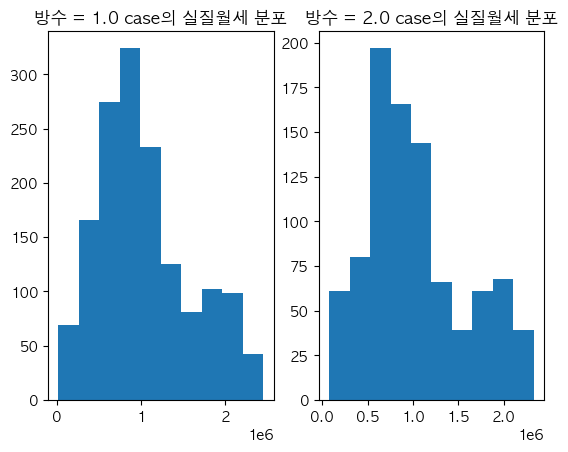

In [31]:
plt.figure()
fig_count = 0

for r_count in list(grouped1.mean(numeric_only=True).index):
    fig_count += 1
    plt.subplot(1, 2, fig_count)
    df = train_raw[(train_raw['방수']==r_count)]
    plt.hist(df['실질월세'])
    plt.title(f'방수 = {r_count} case의 실질월세 분포')

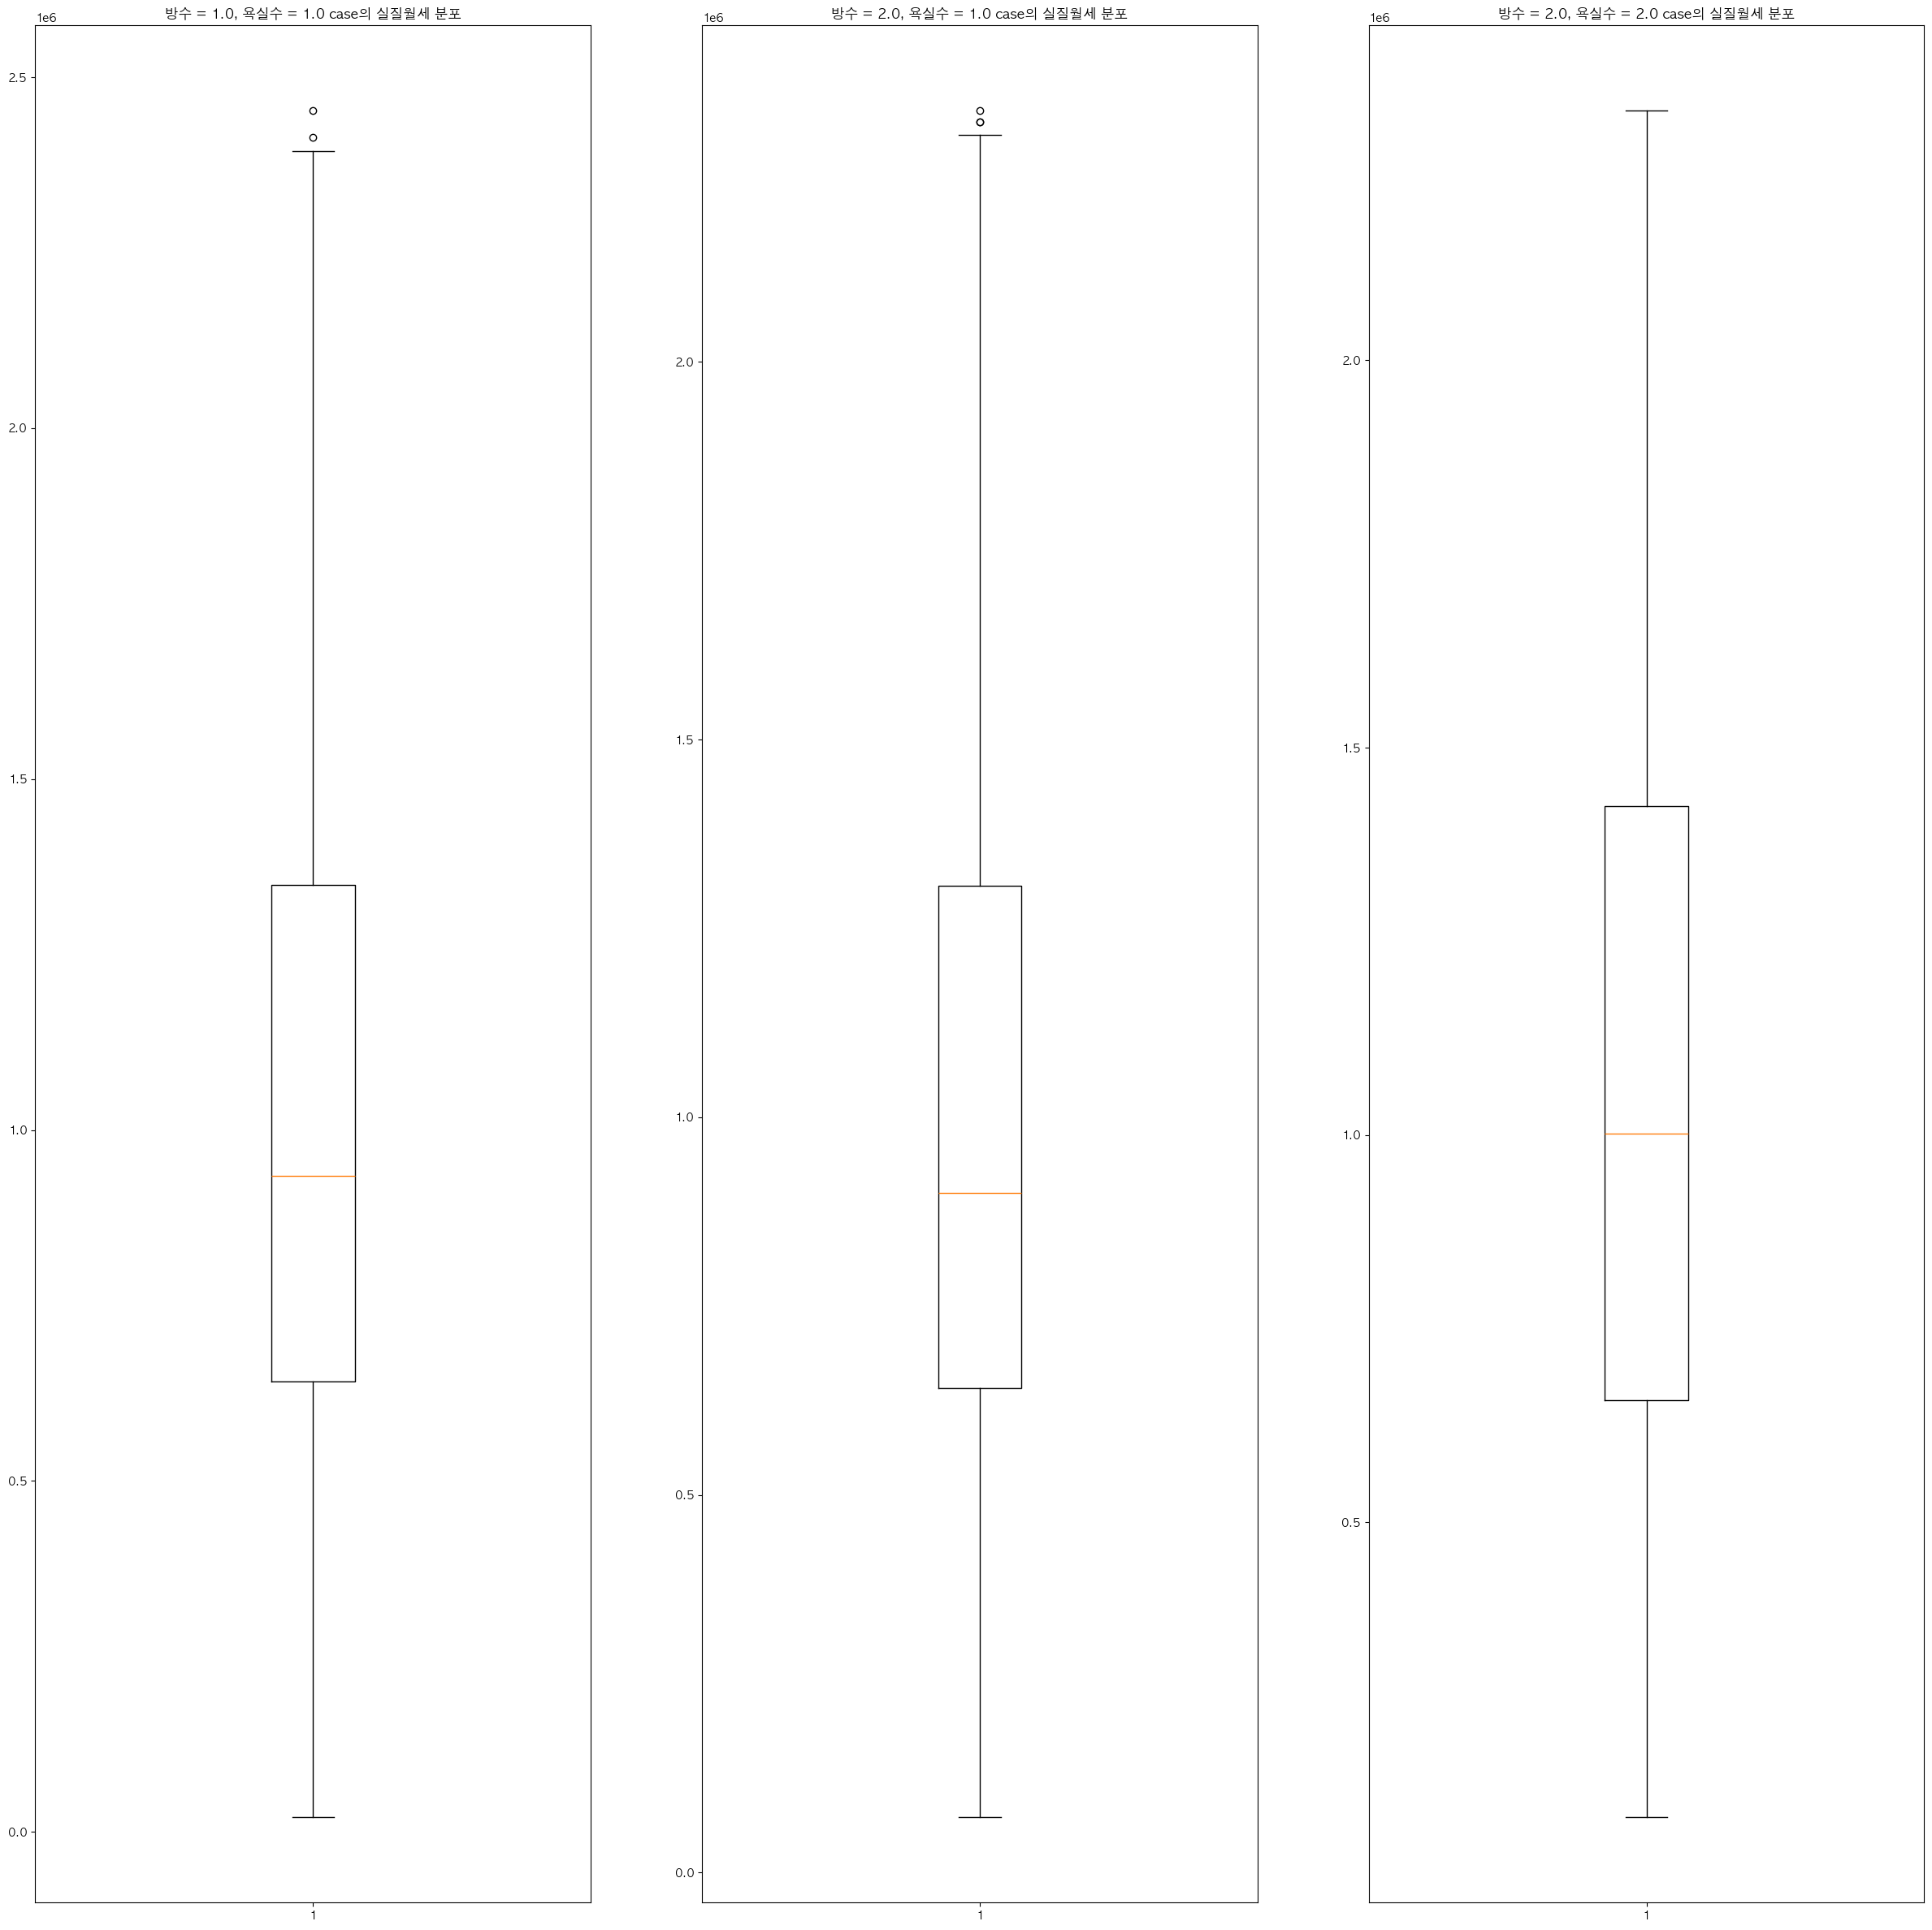

In [30]:
plt.figure(figsize=(30, 30))
fig_count = 0

for idx in list(grouped.median(numeric_only=True).index):
    r_count, t_count = idx
    fig_count += 1
    plt.subplot(1, 3, fig_count)
    df = train_raw[(train_raw['방수']==r_count) & (train_raw['욕실수'] == t_count)]
    plt.boxplot(df['실질월세'])
    plt.title(f'방수 = {r_count}, 욕실수 = {t_count} case의 실질월세 분포')

In [16]:
train_raw['방수'].value_counts()

방수
1.0    1515
2.0     921
Name: count, dtype: int64

In [17]:
train_raw['욕실수'].value_counts()

욕실수
1.0    2350
2.0      84
Name: count, dtype: int64

## 결측치 처리
- 전용면적, 방수, 욕실수 모두 NaN일 경우 drop(보류)

### 전용면적
1. 방수 및 욕실수 별로 group by해서 평균 or 중앙값으로 대체한다.
2. 그럼에도 전용면적이 NaN인 경우(방수 or 욕실수 결측치 존재의 경우) 아래 방법 중 택 1
    2-1. 관리비 기준
    2-2. 보증금 및 월세 기준

### 방수
- 보증금, 월세, 관리비 기반으로 채워보기

### 욕실수
- 보증금, 월세, 관리비 기반으로 채워보기

### 게재일
- 월
- 주말여부

### 방향, 총주차대수, 주차가능, 해당층 및 총층
- 사용X -> column drop

In [18]:
drop_col = [
    '방향',
    '해당층', 
    '총층', 
    '주차가능여부',
    '총주차대수'
]

train_raw.drop(drop_col, axis = 1, inplace = True)

In [19]:
# train_raw = train_raw[train_raw['방수'].isna() == False]

In [20]:
train_raw

,ID,매물확인방식,보증금,월세,전용면적,방수,욕실수,관리비,중개사무소,제공플랫폼,게재일,허위매물여부,실질월세
0,TRAIN_0000,현장확인,402500000.0,470000,NaN,1.0,1.0,96,t93Nt6I2I0,B플랫폼,2024-10-09,0,2.147083e+06
1,TRAIN_0001,현장확인,170500000.0,200000,NaN,2.0,1.0,0,q39iV5J4E6,D플랫폼,2024-12-26,0,9.104167e+05
2,TRAIN_0002,전화확인,114000000.0,380000,NaN,1.0,1.0,0,b03oE4G3F6,A플랫폼,2024-11-28,0,8.550000e+05
3,TRAIN_0003,현장확인,163500000.0,30000,36.30,2.0,1.0,10,G52Iz8V2B9,A플랫폼,2024-11-26,0,7.112500e+05
4,TRAIN_0004,현장확인,346000000.0,530000,NaN,2.0,1.0,0,N45gM0M7R0,B플랫폼,2024-06-25,1,1.971667e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2447,TRAIN_2447,서류확인,159000000.0,550000,48.95,2.0,1.0,0,d22DX4Y4P8,B플랫폼,2024-11-16,0,1.212500e+06
2448,TRAIN_2448,서류확인,158500000.0,750000,NaN,1.0,1.0,2,g99sy3I3R8,A플랫폼,2024-10-06,0,1.410417e+06
2449,TRAIN_2449,전화확인,329000000.0,610000,17.50,1.0,1.0,10,G52Iz8V2B9,B플랫폼,2024-05-15,0,1.980833e+06
2450,TRAIN_2450,현장확인,31000000.0,400000,22.87,2.0,1.0,8,m69GM9O9B3,B플랫폼,2024-08-06,0,5.291667e+05


In [21]:
train_raw.isna().sum()

ID          0
매물확인방식      0
보증금         0
월세          0
전용면적      787
방수         16
욕실수        18
관리비         0
중개사무소       0
제공플랫폼       0
게재일         0
허위매물여부      0
실질월세        0
dtype: int64

In [22]:
train_raw[train_raw['욕실수'].isna() == True] 

,ID,매물확인방식,보증금,월세,전용면적,방수,욕실수,관리비,중개사무소,제공플랫폼,게재일,허위매물여부,실질월세
37,TRAIN_0037,현장확인,25000000.0,520000,NaN,NaN,NaN,4,k74XT0T1B8,D플랫폼,2024-10-06,0,6.241667e+05
76,TRAIN_0076,전화확인,81000000.0,70000,NaN,NaN,NaN,0,K48zc2G4K8,D플랫폼,2025-01-04,0,4.075000e+05
88,TRAIN_0088,현장확인,151000000.0,50000,NaN,NaN,NaN,0,M02bn7Y4P0,D플랫폼,2025-01-16,0,6.791667e+05
153,TRAIN_0153,현장확인,167000000.0,380000,NaN,NaN,NaN,0,c14YI4Z7E6,D플랫폼,2024-08-29,0,1.075833e+06
163,TRAIN_0163,현장확인,128000000.0,360000,NaN,1.0,NaN,0,l96pE8X9A9,D플랫폼,2024-09-30,0,8.933333e+05
339,TRAIN_0339,서류확인,194000000.0,360000,NaN,NaN,NaN,0,M02bn7Y4P0,D플랫폼,2025-01-13,0,1.168333e+06
456,TRAIN_0456,전화확인,65500000.0,100000,NaN,NaN,NaN,9,l84az9J6A2,C플랫폼,2024-10-15,0,3.729167e+05
515,TRAIN_0515,전화확인,189500000.0,500000,NaN,NaN,NaN,0,M02bn7Y4P0,D플랫폼,2024-07-25,0,1.289583e+06
546,TRAIN_0546,서류확인,116000000.0,180000,NaN,NaN,NaN,9,o07ZC4L7V4,C플랫폼,2024-11-07,0,6.633333e+05
686,TRAIN_0686,현장확인,181500000.0,520000,NaN,NaN,NaN,0,M02bn7Y4P0,D플랫폼,2024-08-15,0,1.276250e+06


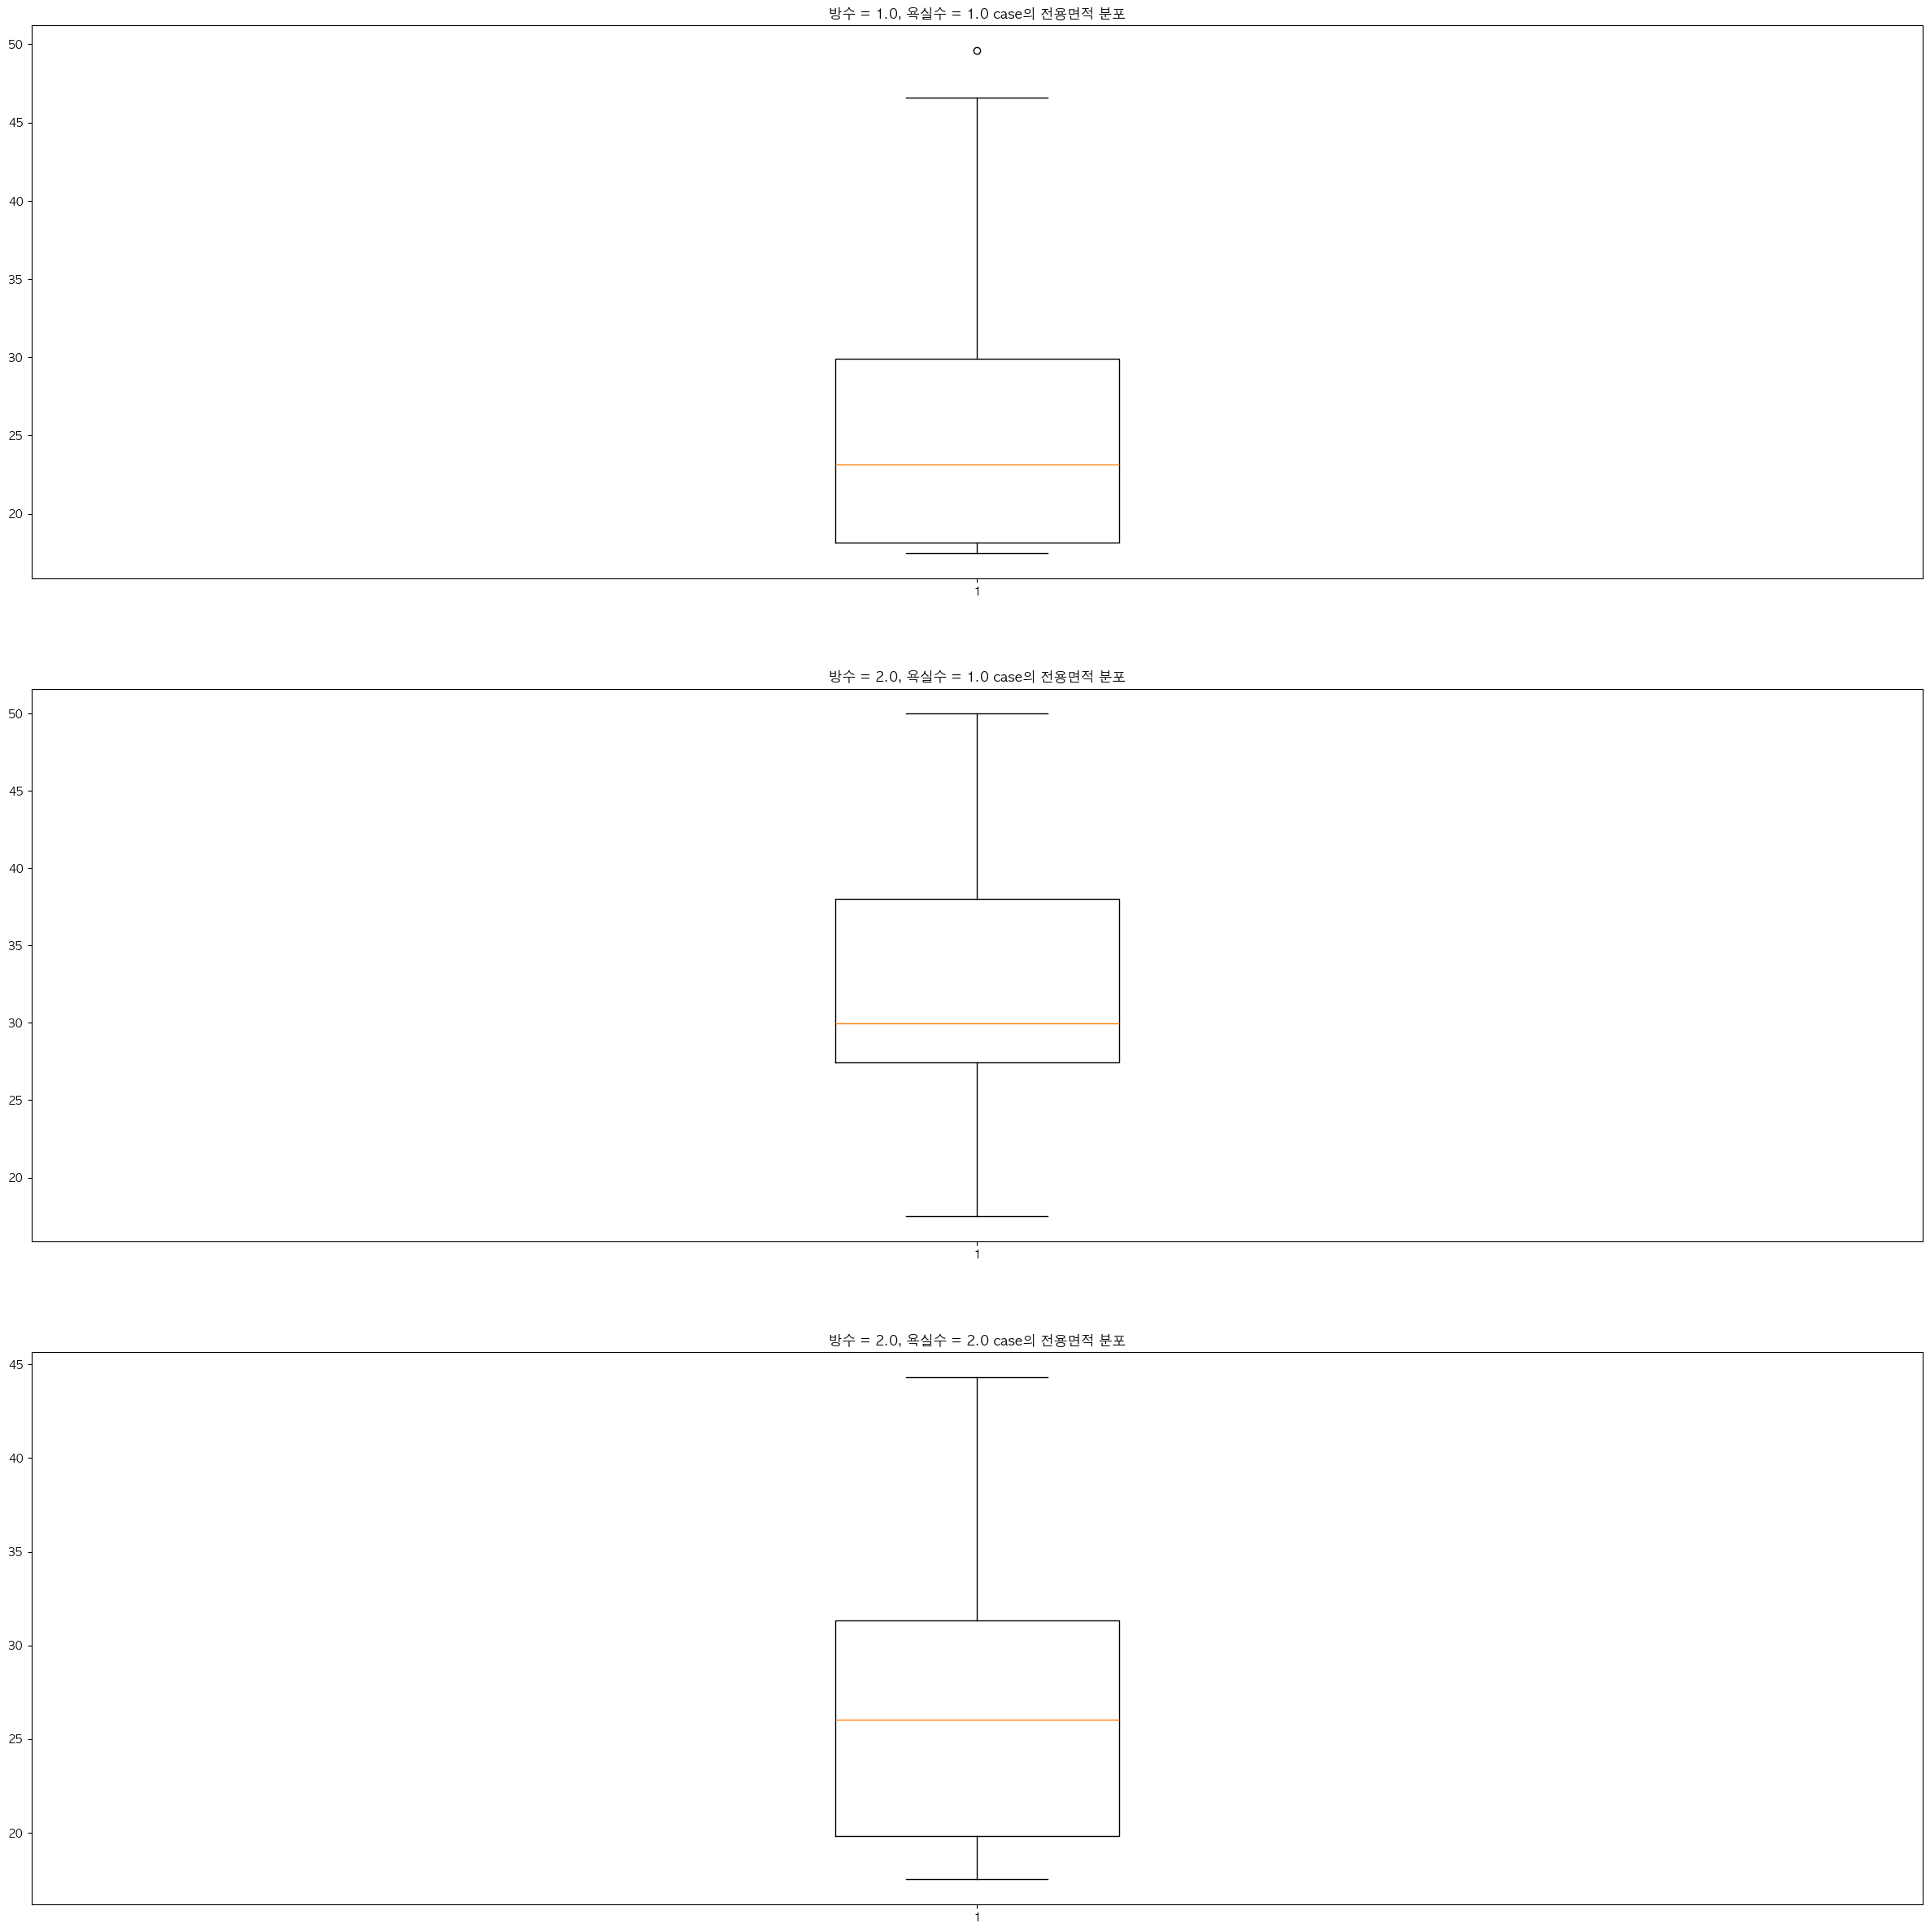

In [22]:
plt.figure(figsize=(30, 30))
fig_count = 0

for idx in list(grouped.median(numeric_only=True).index):
    r_count, t_count = idx
    fig_count += 1
    plt.subplot(3, 1, fig_count)
    df = train_raw[(train_raw['방수']==r_count) & (train_raw['욕실수'] == t_count)]
    plt.boxplot(df['전용면적'].dropna())
    plt.title(f'방수 = {r_count}, 욕실수 = {t_count} case의 전용면적 분포')

In [31]:
train_raw[train_raw['욕실수'].isna() == True] 

'''
-  2개의 row이므로 직접 결측치 보간
- TRAIN_0163의 경우
    - 방수가 1개 였던 곳은 모두 욕실수가 1개였기 때문에 욕실수를 1로 대치
    - 전용면적의 경우, 보증금, 월세가 모두 중앙치에 근접하여 전용면적 중앙값으로 대치

- TRAIN_1901의 경우
    - 월세 및 전용면적을 고려하여 욕실수를 1로 대치
'''

'\n-  2개의 row이므로 직접 결측치 보간\n- TRAIN_0163의 경우\n    - 방수가 1개 였던 곳은 모두 욕실수가 1개였기 때문에 욕실수를 1로 대치\n    - 전용면적의 경우, 보증금, 월세가 모두 중앙치에 근접하여 전용면적 중앙값으로 대치\n\n- TRAIN_1901의 경우\n    - 월세 및 전용면적을 고려하여 욕실수를 1로 대치\n'

In [32]:
fill_na_manual1 = train_raw[(train_raw['방수']== 1) & (train_raw['욕실수'] == 1)]
fill_na_manual1.describe()

,보증금,월세,전용면적,방수,욕실수,관리비,허위매물여부
count,1.514000e+03,1514.000000,1140.000000,1514.0,1514.0,1514.000000,1514.000000
mean,1.577137e+08,387067.371202,25.078175,1.0,1.0,5.963672,0.112285
std,1.213684e+08,211187.088159,7.218567,0.0,0.0,5.807612,0.315822
min,5.000000e+06,0.000000,17.500000,1.0,1.0,0.000000,0.000000
25%,7.500000e+07,210000.000000,18.180000,1.0,1.0,0.000000,0.000000
50%,1.317500e+08,380000.000000,23.140000,1.0,1.0,5.000000,0.000000
75%,1.890000e+08,560000.000000,29.925000,1.0,1.0,10.000000,0.000000
max,4.090000e+08,750000.000000,49.600000,1.0,1.0,96.000000,1.000000


In [33]:
train_raw.loc[163, '욕실수'] = 1.0
train_raw.loc[163,'전용면적'] = train_raw[(train_raw['방수']== 1) & (train_raw['욕실수'] == 1)].describe().loc['50%', '전용면적']

In [34]:
train_raw.loc[1901, '욕실수'] = 2.0

In [35]:
train_raw.isna().sum()

ID          0
매물확인방식      0
보증금         0
월세          0
전용면적      770
방향          0
방수          0
욕실수         0
관리비         0
중개사무소       0
제공플랫폼       0
게재일         0
허위매물여부      0
dtype: int64

(array([497., 182., 218., 266., 159., 128.,  89.,  78.,  31.,  17.]),
 array([17.5  , 20.747, 23.994, 27.241, 30.488, 33.735, 36.982, 40.229,
        43.476, 46.723, 49.97 ]),
 <BarContainer object of 10 artists>)

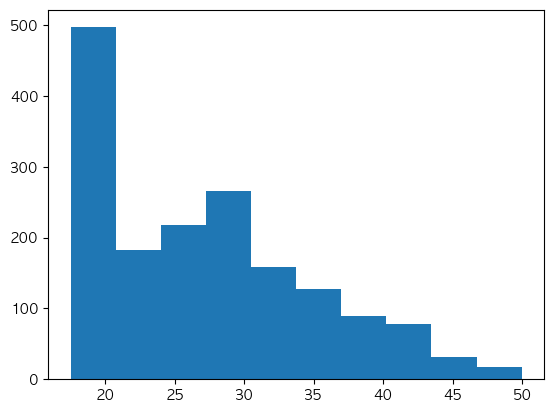

In [24]:
plt.hist(train_raw['전용면적'])

In [ ]:
# train_raw['전용면적'].fillna(
#     lambda row: 
# )

# 사용 Column

## `X`
- 매물확인방식
- 실질월세(전월세 전환율을 통해 보증금과 월세를 통일)
    - 보증금
    - 월세
- 전용면적
- 방수
- 욕실수
- 관리비
- 중개사무소
- 제공플랫폼(보류)
- 게재일

## `y`
- 허위매물여부 -> Categorical

## Categorical 변수 Encoding

### LabelEncoder
- 방수
- 욕실수
- 중개사무소
- 제공플랫폼

### OneHotEncoder
- 매물확인방식

